<a href="https://colab.research.google.com/github/manubastidas/programacionCientifica/blob/eval2-GomezGomez/Evaluacion2/gomezgomez/solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
!sudo apt-get update
!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np

from scipy.special import comb
from scipy.interpolate import CubicSpline, make_interp_spline

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color"    : "gray",
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (4,046 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cm-super is already the newest version (0.3.4-17).

In [27]:
#Fase n°1, generacion de los datos y entrenamiento de las redes neuronales

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Cargar los datos
datos = np.load('datos_4098.npz')
X = datos['X']       # Señales: (45, 256)
y = datos['y']       # Regimen de datos: (45,)
t = datos['t']       # Vector de tiempo: (256,)

def predict(params, X_batch):
    W1, W2 = params
    # Aplicamos W1 a cada señal de la matriz X
    hidden = jnp.tanh(jnp.dot(X_batch, W1.T))
    X_hat = jnp.dot(hidden, W2.T)
    return X_hat

def mse_loss(params, X_batch):
    X_hat = predict(params, X_batch)
    return jnp.mean((X_hat - X_batch)**2)

def init_fourier(t, key, K=30):
    # W1: Construimos la Base de Fourier manualmente en numpy
    W1 = np.zeros((2 * K, len(t)))
    for k in range(1, K + 1):
        W1[2 * (k - 1), :] = np.sin(2 * jnp.pi * k * t)
        W1[2 * (k - 1) + 1, :] = np.cos(2 * jnp.pi * k * t)

    # W2: Inicialización aleatoria con factor de escala pequeño
    key_w2, _ = jax.random.split(key)
    W2 = jax.random.normal(key_w2, (len(t), 2 * K)) * 0.1

    return [jnp.array(W1), W2]

def init_random(t, key, K=30):
    key_w1, key_w2 = jax.random.split(key)
    # W1 y W2 puramente aleatorias
    W1 = jax.random.normal(key_w1, (2 * K, len(t))) * 0.1
    W2 = jax.random.normal(key_w2, (len(t), 2 * K)) * 0.1
    return [W1, W2]

@jax.jit
def update(params, X_batch, lr=0.1):
    loss, grads = jax.value_and_grad(mse_loss)(params, X_batch)
    # Descenso de gradiente estándar
    new_params = [p - lr * g for p, g in zip(params, grads)]
    return new_params, loss

def train_network(params, X_train, epochs=2000, lr=0.1):
    loss_history = []
    for epoch in range(epochs):
        params, loss = update(params, X_train, lr)
        loss_history.append(loss)
    return params, loss_history

# Filtrar solo el régimen 0 (sin dispersión)
X_regimen_0 = X[y == 0]

# Inicializar semillas de JAX
key = jax.random.PRNGKey(4098)
key_fourier, key_random = jax.random.split(key)

# 1. Entrenar con inicialización de Fourier
params_fourier = init_fourier(t, key_fourier)
params_fourier_final, loss_fourier = train_network(params_fourier, X_regimen_0)

# 2. Entrenar con inicialización Aleatoria
params_random = init_random(t, key_random)
params_random_final, loss_random = train_network(params_random, X_regimen_0)


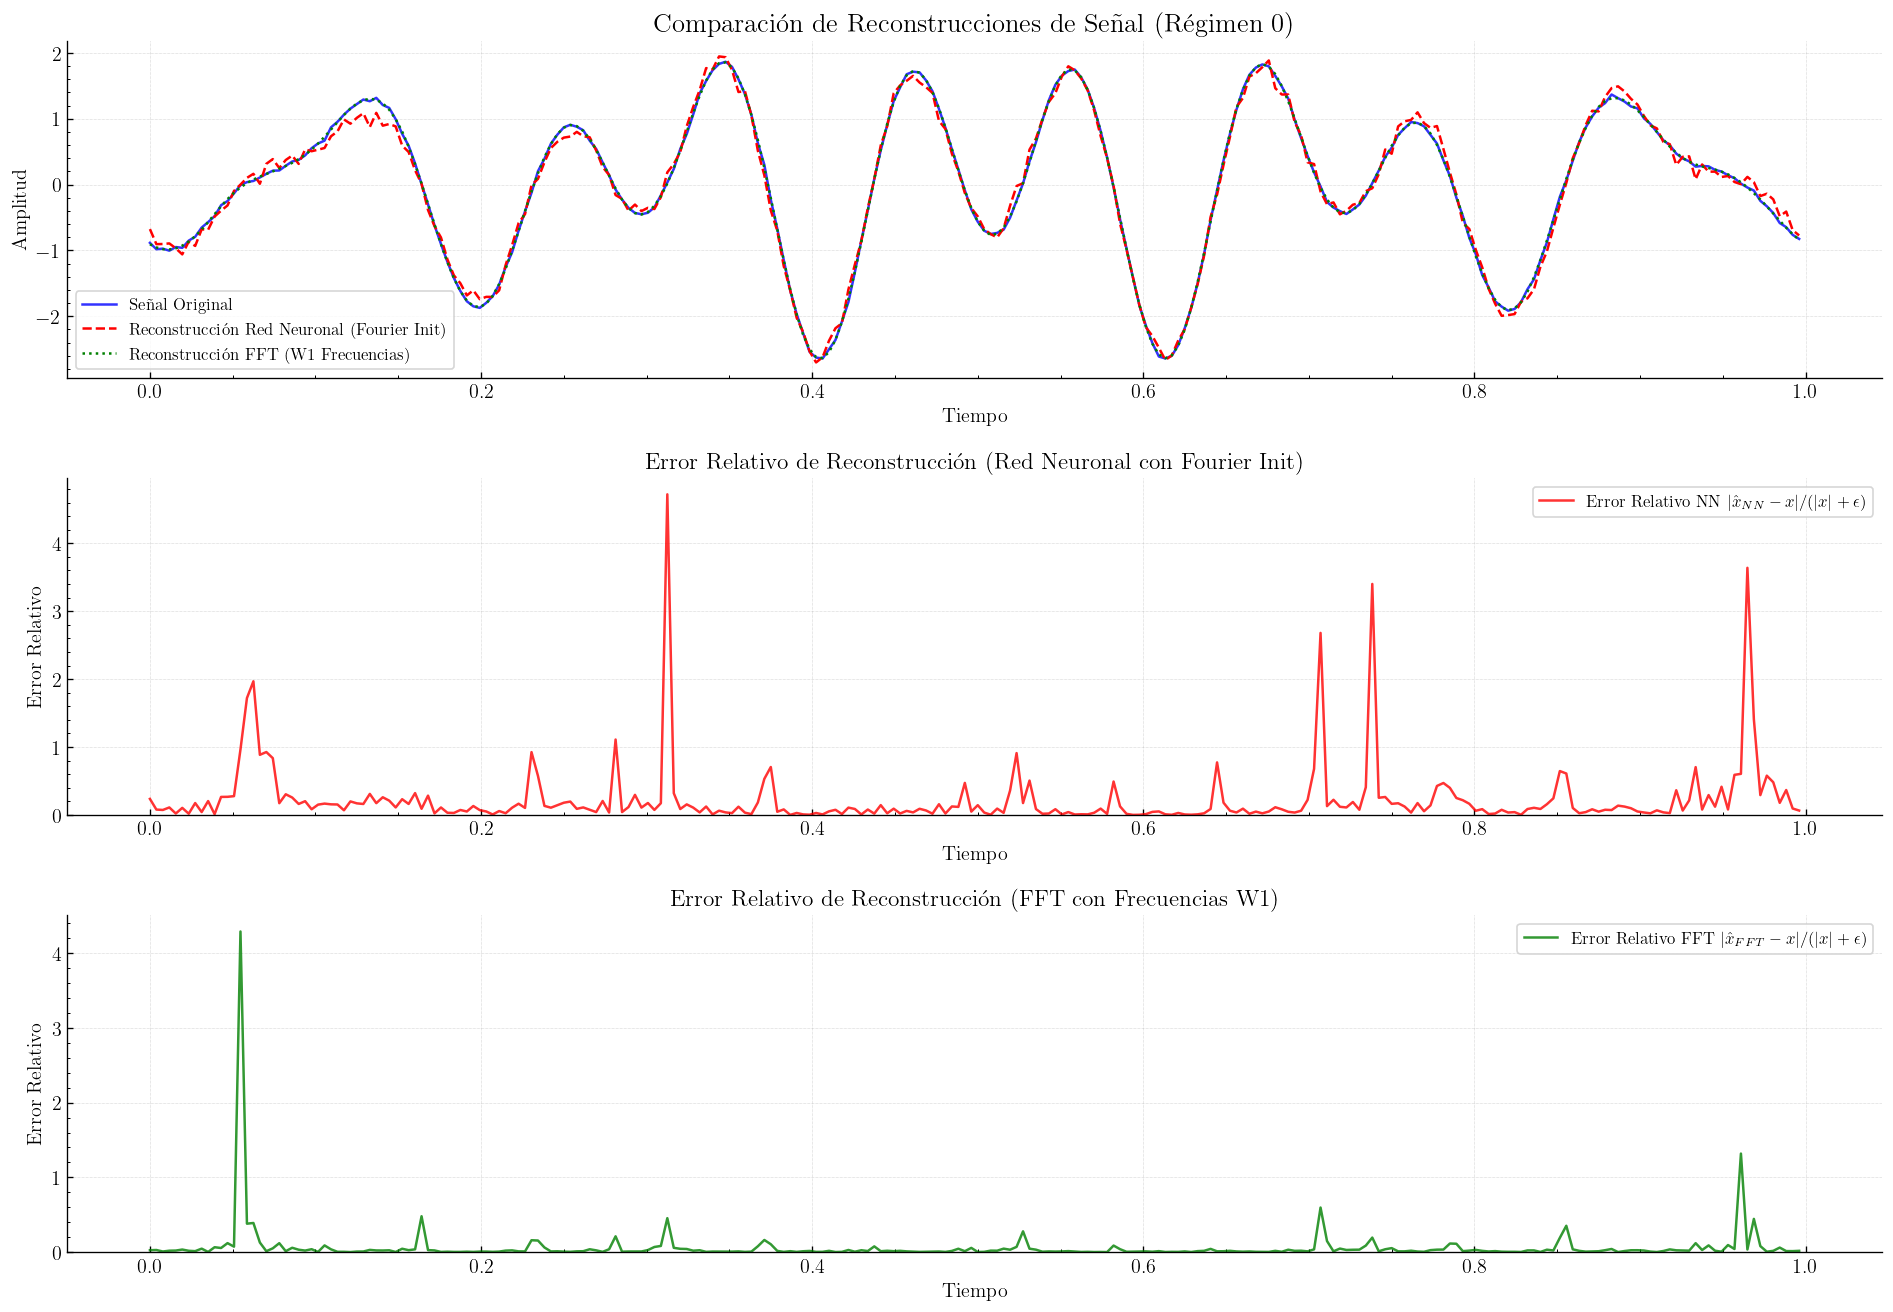

Máximo Error Relativo entre la Señal Original y la Reconstrucción FFT (W1 Frecuencias): 4.2916


In [40]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Seleccionar una señal de ejemplo del régimen 0
sample_signal_idx = 0  # Tomamos la primera señal del régimen 0
original_signal = X_regimen_0[sample_signal_idx]

# 1. Reconstrucción con la red neuronal (inicialización Fourier)
reconstructed_nn = predict(params_fourier_final, jnp.expand_dims(original_signal, axis=0))[0]

# 2. Reconstrucción utilizando FFT y solo las frecuencias de W1
N = len(original_signal)
dt = t[1] - t[0]

# Calcular la FFT de la señal original
fft_original = np.fft.fft(original_signal)
frequencies = np.fft.fftfreq(N, d=dt)

# Crear un array para la FFT filtrada, inicializado a cero
filtered_fft = np.zeros_like(fft_original, dtype=complex)

# Extraer las frecuencias utilizadas en la construcción de W1 de la inicialización Fourier
K_fourier = 30 # Definido en init_fourier
T_period = N * dt # Duración total de la observación. Anteriormente era t[-1] - t[0].

# Aquí vamos a construir un conjunto de frecuencias simétricas para la IFFT
# Las frecuencias en w1_basis_frequencies son solo las positivas
w1_positive_basis_freqs = np.array([k / T_period for k in range(1, K_fourier + 1)])

# Identificar los índices de estas frecuencias en el array 'frequencies'
for freq in w1_positive_basis_freqs:
    # Buscar el índice de la frecuencia positiva (o la más cercana)
    idx_pos = np.argmin(np.abs(frequencies - freq))
    if np.abs(frequencies[idx_pos] - freq) < 1e-6: # Asegurarse de que es una coincidencia cercana
        filtered_fft[idx_pos] = fft_original[idx_pos]

        # Para la frecuencia negativa conjugada
        # La frecuencia negativa correspondiente sería -freq
        idx_neg = np.argmin(np.abs(frequencies - (-freq)))
        if np.abs(frequencies[idx_neg] - (-freq)) < 1e-6:
            filtered_fft[idx_neg] = fft_original[idx_neg]

# Realizar la IFFT para obtener la señal reconstruida en el dominio del tiempo
reconstructed_fft = np.fft.ifft(filtered_fft).real

# Calcular errores relativos
epsilon = 1e-8
relative_error_nn = jnp.abs(reconstructed_nn - original_signal) / (jnp.abs(original_signal) + epsilon)
relative_error_fft = jnp.abs(reconstructed_fft - original_signal) / (jnp.abs(original_signal) + epsilon)

# ---- Gráficas de Comparación ----

plt.figure(figsize=(16, 12))

# Subtrama 1: Comparación de Señales Reconstruidas con la Original
plt.subplot(3, 1, 1)
plt.plot(t, original_signal, label='Señal Original', color='blue', alpha=0.8)
plt.plot(t, reconstructed_nn, label='Reconstrucción Red Neuronal (Fourier Init)', color='red', linestyle='--')
plt.plot(t, reconstructed_fft, label='Reconstrucción FFT (W1 Frecuencias)', color='green', linestyle=':')
plt.title('Comparación de Reconstrucciones de Señal (Régimen 0)', fontsize=16)
plt.xlabel('Tiempo', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)

# Subtrama 2: Error Relativo de la Reconstrucción de la Red Neuronal
plt.subplot(3, 1, 2)
plt.plot(t, relative_error_nn, label=r'Error Relativo NN $|\hat{x}_{NN} - x| / (|x| + \epsilon)$', color='red', alpha=0.8)
plt.title('Error Relativo de Reconstrucción (Red Neuronal con Fourier Init)', fontsize=14)
plt.xlabel('Tiempo', fontsize=12)
plt.ylabel('Error Relativo', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.ylim(bottom=0)

# Subtrama 3: Error Relativo de la Reconstrucción por FFT (W1 Frecuencias)
plt.subplot(3, 1, 3)
plt.plot(t, relative_error_fft, label=r'Error Relativo FFT $|\hat{x}_{FFT} - x| / (|x| + \epsilon)$', color='green', alpha=0.8)
plt.title('Error Relativo de Reconstrucción (FFT con Frecuencias W1)', fontsize=14)
plt.xlabel('Tiempo', fontsize=12)
plt.ylabel('Error Relativo', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.ylim(bottom=0)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

max_relative_error_fft_w1 = jnp.max(relative_error_fft)
print(f"Máximo Error Relativo entre la Señal Original y la Reconstrucción FFT (W1 Frecuencias): {max_relative_error_fft_w1:.4f}")

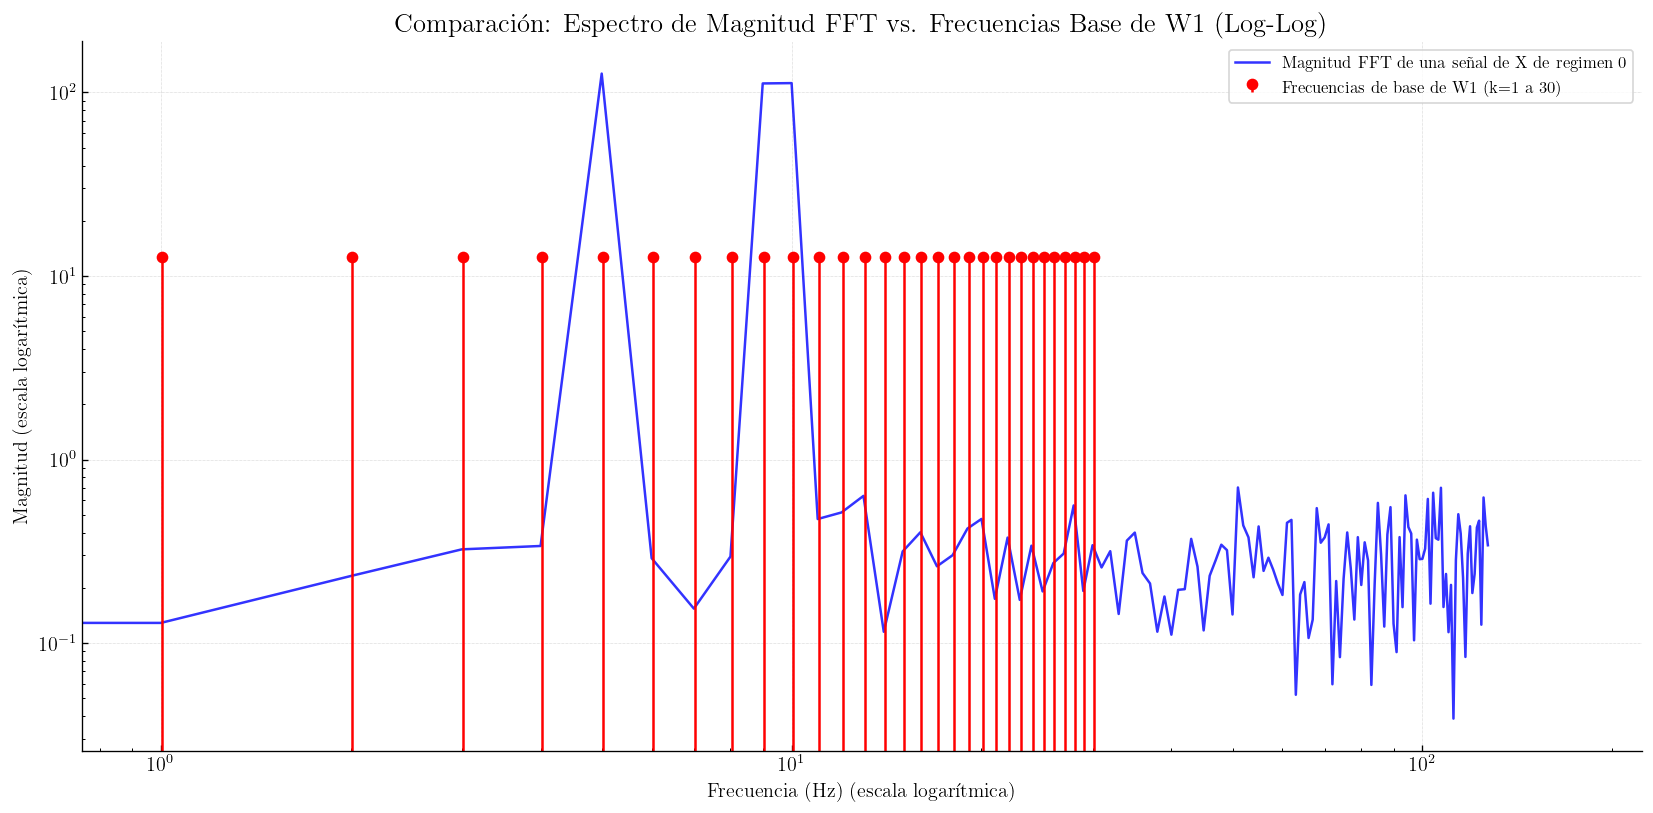

La señal media cuadrática del dataset (X**2).mean() es: 0.7120


In [23]:
#Fase n°2, comparacion de las señales por medio de fft, calculo de la señal media

import numpy as np
import matplotlib.pyplot as plt

# Seleccionar una señal de ejemplo del régimen 0 y calcular su FFT
sample_signal = X_regimen_0[0] # Tomamos la primera señal del régimen 0
fft_signal = np.fft.fft(sample_signal)

# Calcular las frecuencias correspondientes a la FFT
N = len(sample_signal) # Número de puntos en la señal
dt = t[1] - t[0]       # Intervalo de tiempo entre muestras (asumiendo t es equiespaciado)
frequencies = np.fft.fftfreq(N, d=dt)

# Solo considerar las frecuencias positivas y sus magnitudes correspondientes para el plot
positive_freq_indices = frequencies >= 0
positive_frequencies = frequencies[positive_freq_indices]
fft_magnitudes = np.abs(fft_signal[positive_freq_indices])

# Extraer las frecuencias utilizadas en la construcción de W1 de la inicialización Fourier
# K se define en init_fourier (en la celda anterior) como 30
K_fourier = 30
T_period = t[-1] - t[0] # Duración total del vector de tiempo
w1_basis_frequencies = np.array([k / T_period for k in range(1, K_fourier + 1)])

# Crear la gráfica de comparación
plt.figure(figsize=(14, 7))

# Graficar la magnitud de la FFT de la señal y marcar las frecuencias de W1
plt.loglog(positive_frequencies, fft_magnitudes, label='Magnitud FFT de una señal de X de regimen 0', color='blue', alpha=0.8)
plt.stem(w1_basis_frequencies, np.ones_like(w1_basis_frequencies) * np.max(fft_magnitudes) * 0.1,
         linefmt='red', markerfmt='ro', basefmt=' ', label=f'Frecuencias de base de W1 (k=1 a {K_fourier})')

plt.title('Comparación: Espectro de Magnitud FFT vs. Frecuencias Base de W1 (Log-Log)', fontsize=16)
plt.xlabel('Frecuencia (Hz) (escala logarítmica)', fontsize=12)
plt.ylabel('Magnitud (escala logarítmica)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim(0.75, None)
plt.tight_layout()
plt.show()

# Imprimir la señal media cuadrática del dataset
mean_squared_X = (X**2).mean()
print(f'La señal media cuadrática del dataset (X**2).mean() es: {mean_squared_X:.4f}')

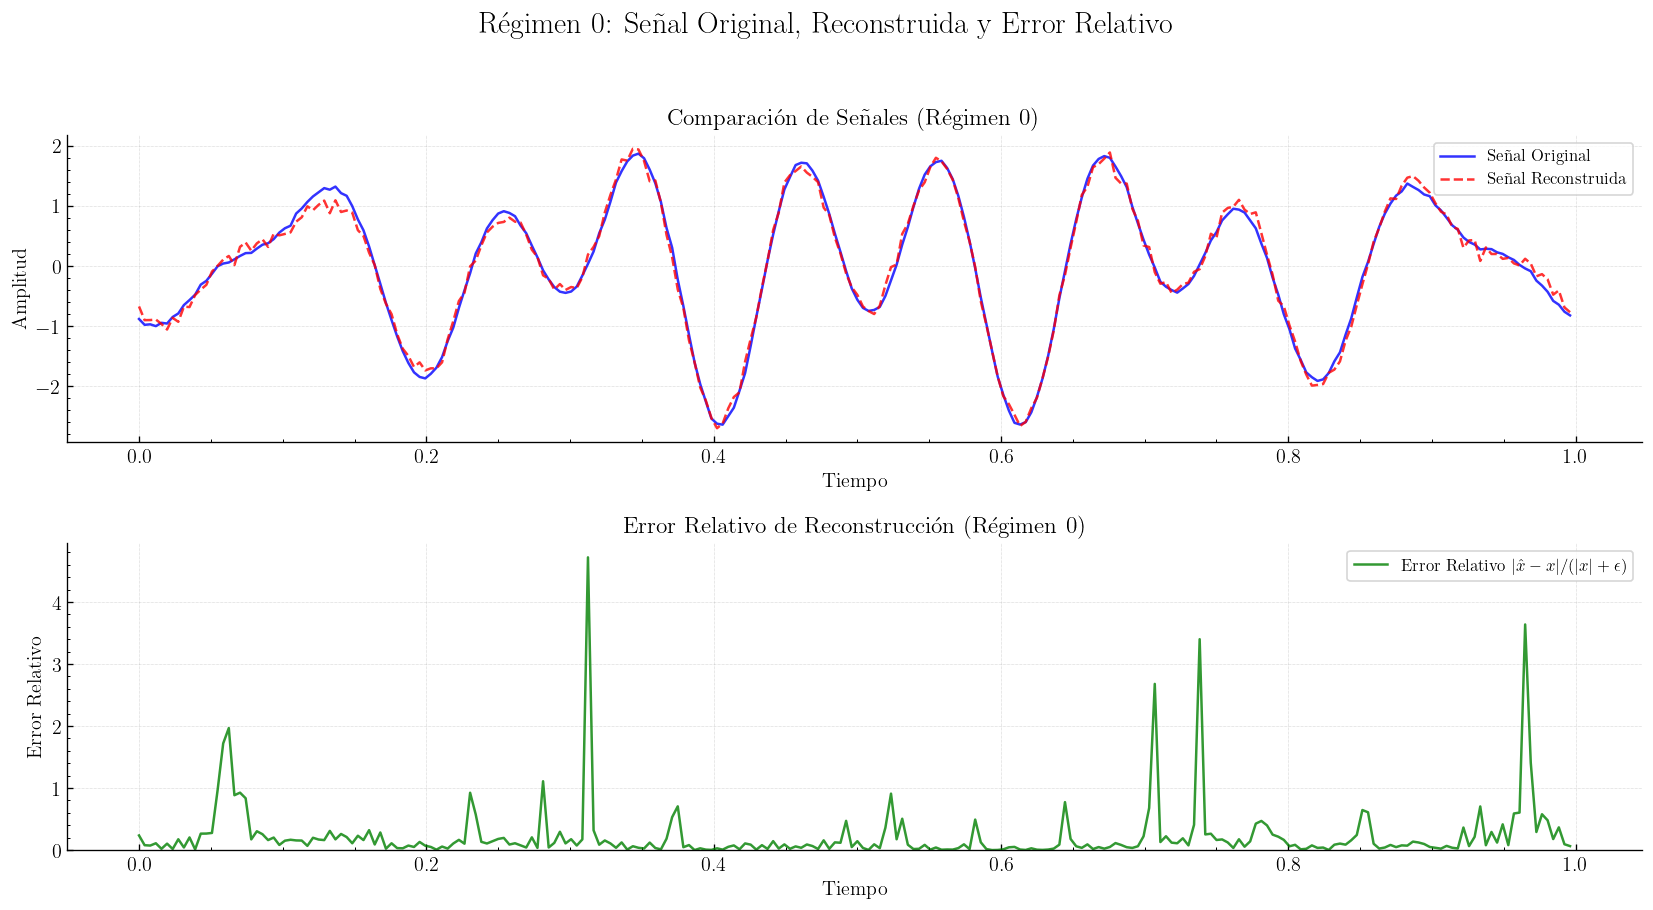

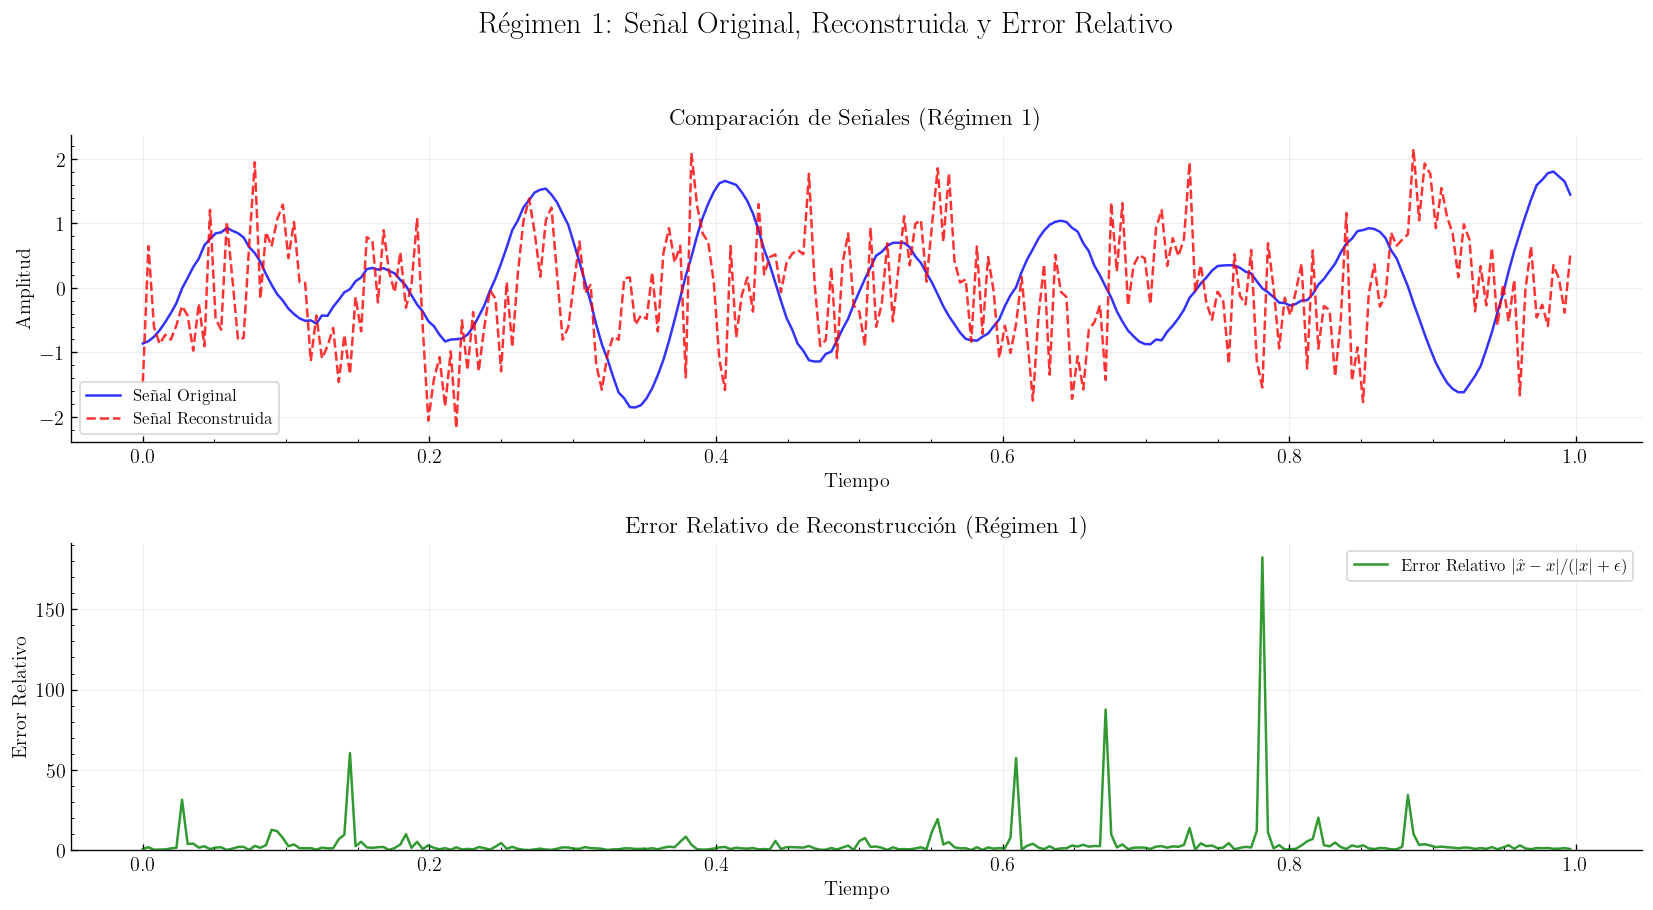

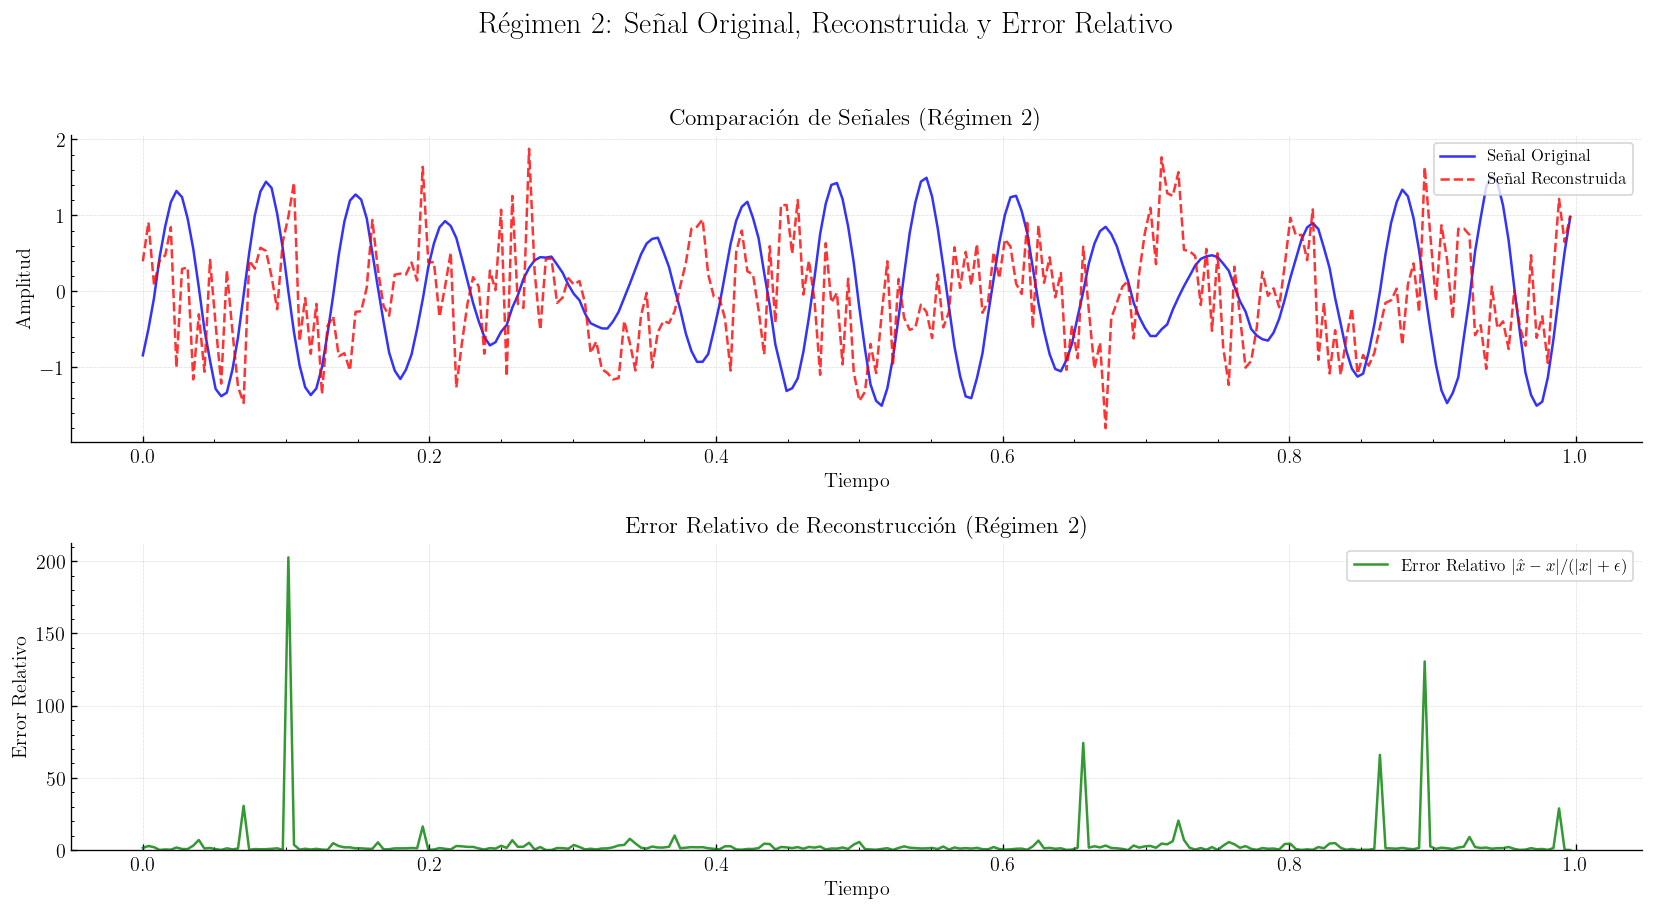

Márgenes de Error (Máximo Error Relativo) por Régimen:
---------------------------------------------------
Régimen 0: 4.7208
Régimen 1: 182.3665
Régimen 2: 202.7079


In [33]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Obtener los regímenes únicos presentes en los datos
unique_regimes = np.unique(y)

for regime in unique_regimes:
    # Encontrar los índices de las señales que pertenecen al régimen actual
    regime_indices = np.where(y == regime)[0]
    if len(regime_indices) == 0:
        print(f"No se encontraron señales para el régimen {regime}")
        continue

    # Tomar la primera señal de este régimen como ejemplo
    sample_index = regime_indices[0]
    original_signal = X[sample_index]

    # Reconstruir la señal utilizando la red entrenada con inicialización de Fourier
    # La función predict espera un lote, así que pasamos una sola señal como un lote de 1
    reconstructed_signal = predict(params_fourier_final, jnp.expand_dims(original_signal, axis=0))[0]

    # Calcular el error relativo elemento a elemento
    # Se añade un pequeño epsilon al denominador para evitar la división por cero
    epsilon = 1e-8
    relative_error = jnp.abs(reconstructed_signal - original_signal) / (jnp.abs(original_signal) + epsilon)

    # Graficar la señal original, la reconstruida y el error relativo
    plt.figure(figsize=(14, 8))
    plt.suptitle(f'Régimen {regime}: Señal Original, Reconstruida y Error Relativo', fontsize=18)

    # Subtrama 1: Señal Original vs. Reconstruida
    plt.subplot(2, 1, 1)
    plt.plot(t, original_signal, label='Señal Original', color='blue', alpha=0.8)
    plt.plot(t, reconstructed_signal, label='Señal Reconstruida', color='red', linestyle='--', alpha=0.8)
    plt.title(f'Comparación de Señales (Régimen {regime})', fontsize=14)
    plt.xlabel('Tiempo', fontsize=12)
    plt.ylabel('Amplitud', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.7)

    # Subtrama 2: Error Relativo
    plt.subplot(2, 1, 2)
    plt.plot(t, relative_error, label=r'Error Relativo $|\hat{x} - x| / (|x| + \epsilon)$', color='green', alpha=0.8)
    plt.title(f'Error Relativo de Reconstrucción (Régimen {regime})', fontsize=14)
    plt.xlabel('Tiempo', fontsize=12)
    plt.ylabel('Error Relativo', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.ylim(bottom=0) # Asegura que el error sea no negativo y comience desde 0

    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Ajusta el diseño para evitar la superposición del título principal
    plt.show()

# Obtener los regímenes únicos presentes en los datos
unique_regimes = np.unique(y)

print("Márgenes de Error (Máximo Error Relativo) por Régimen:")
print("---------------------------------------------------")

for regime in unique_regimes:
    # Encontrar los índices de las señales que pertenecen al régimen actual
    regime_indices = np.where(y == regime)[0]
    if len(regime_indices) == 0:
        print(f"No se encontraron señales para el régimen {regime}")
        continue

    # Tomar la primera señal de este régimen como ejemplo
    sample_index = regime_indices[0]
    original_signal = X[sample_index]

    # Reconstruir la señal utilizando la red entrenada con inicialización de Fourier
    # La función predict espera un lote, así que pasamos una sola señal como un lote de 1
    reconstructed_signal = predict(params_fourier_final, jnp.expand_dims(original_signal, axis=0))[0]

    # Calcular el error relativo elemento a elemento
    # Se añade un pequeño epsilon al denominador para evitar la división por cero
    epsilon = 1e-8
    relative_error = jnp.abs(reconstructed_signal - original_signal) / (jnp.abs(original_signal) + epsilon)

    # Calcular el error máximo relativo para este régimen
    max_relative_error = jnp.max(relative_error)
    print(f"Régimen {regime}: {max_relative_error:.4f}")

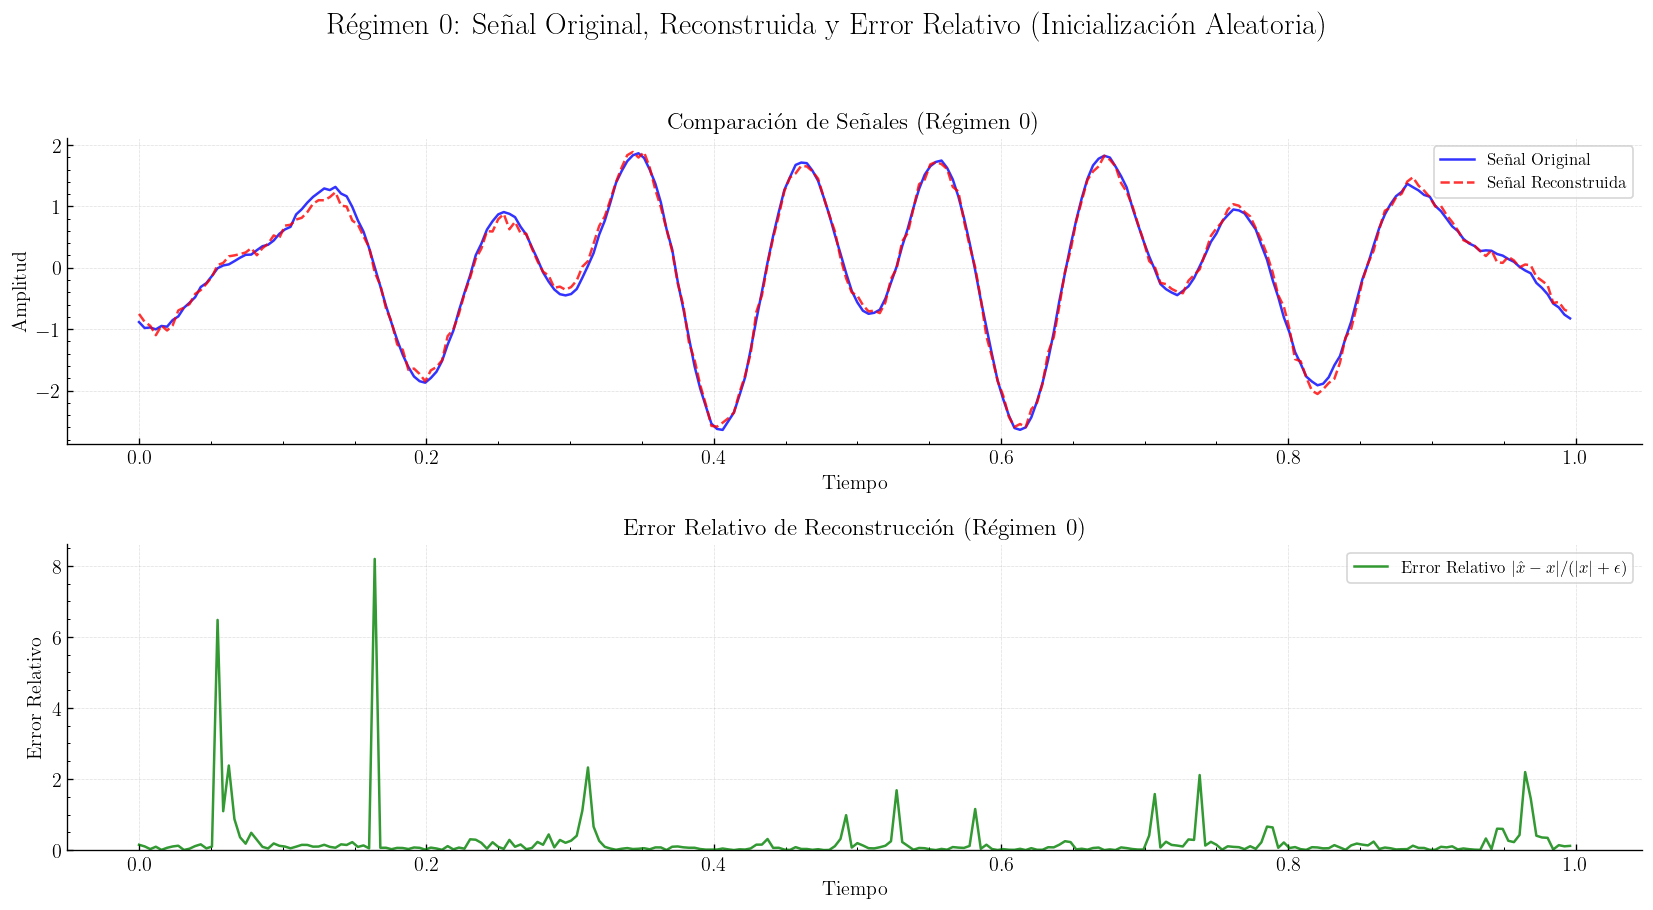

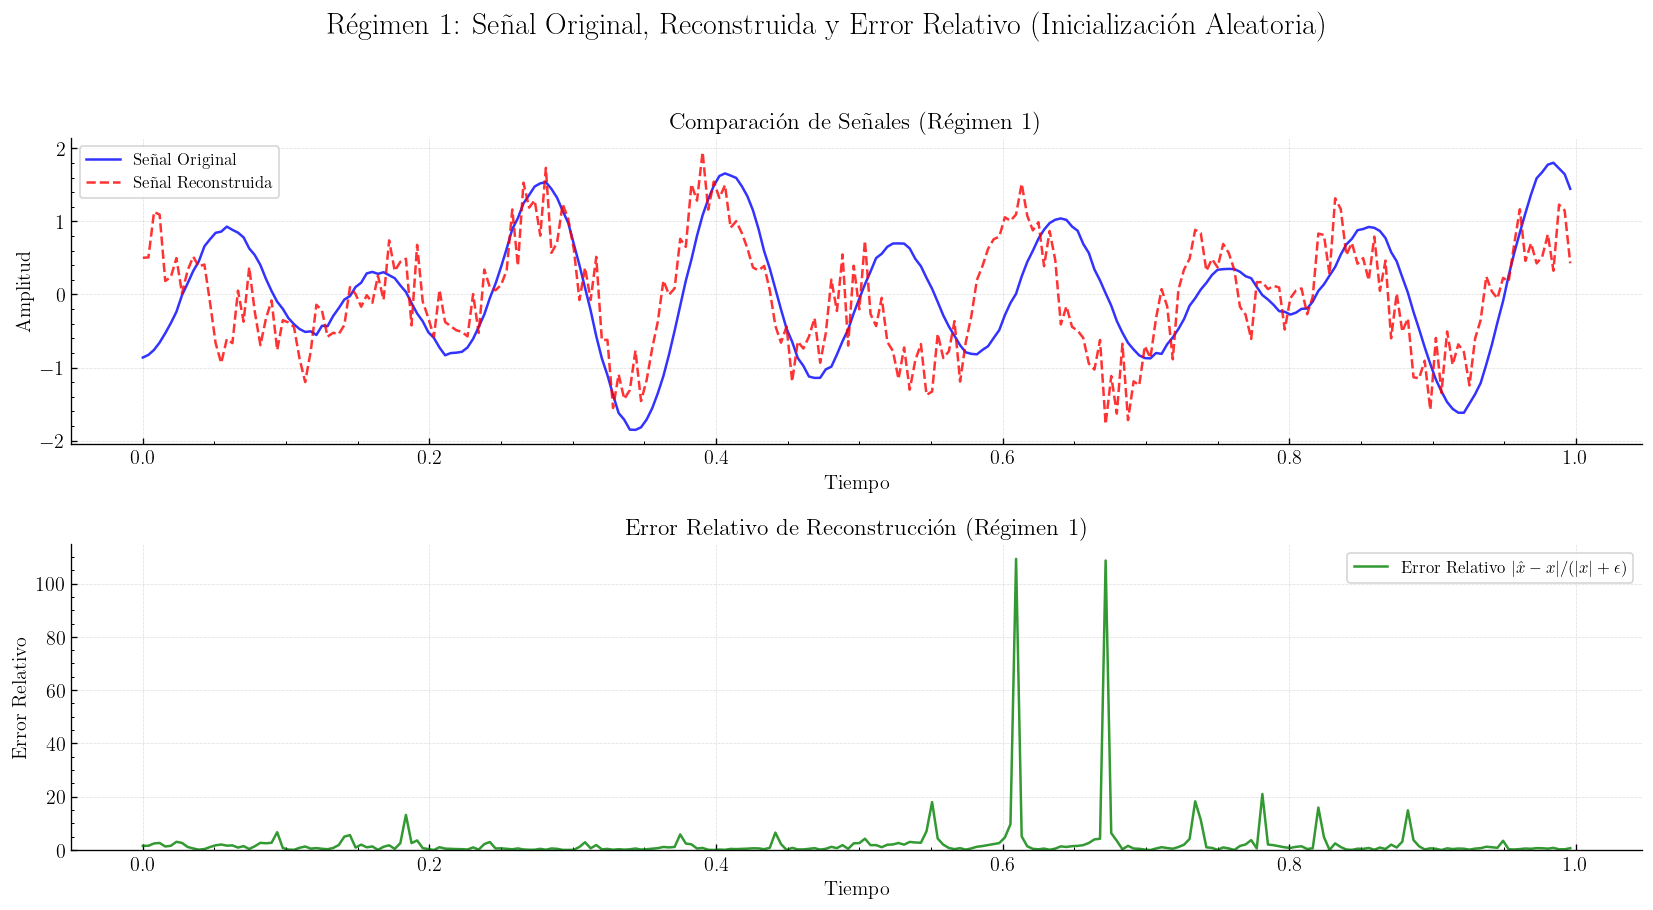

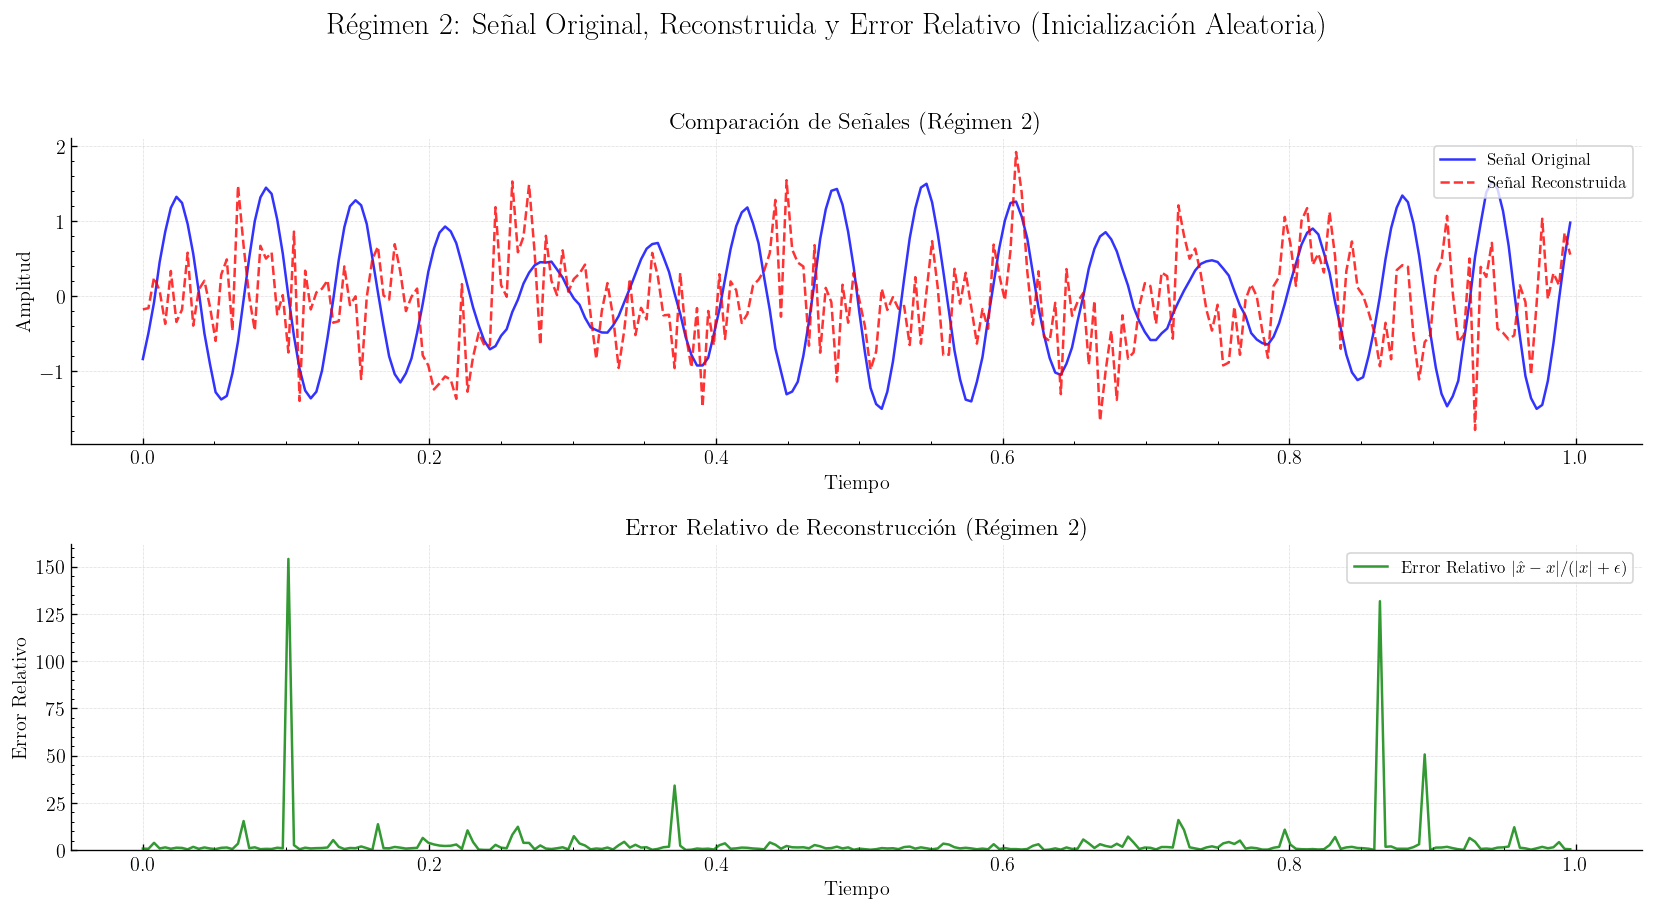

Márgenes de Error (Máximo Error Relativo) por Régimen (Inicialización Aleatoria):
--------------------------------------------------------------------------------
Régimen 0: 8.1945
Régimen 1: 109.2355
Régimen 2: 154.0970


In [36]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Obtener los regímenes únicos presentes en los datos
unique_regimes = np.unique(y)

for regime in unique_regimes:
    # Encontrar los índices de las señales que pertenecen al régimen actual
    regime_indices = np.where(y == regime)[0]
    if len(regime_indices) == 0:
        print(f"No se encontraron señales para el régimen {regime}")
        continue

    # Tomar la primera señal de este régimen como ejemplo
    sample_index = regime_indices[0]
    original_signal = X[sample_index]

    # Reconstruir la señal utilizando la red entrenada con inicialización aleatoria
    # La función predict espera un lote, así que pasamos una sola señal como un lote de 1
    reconstructed_signal = predict(params_random_final, jnp.expand_dims(original_signal, axis=0))[0]

    # Calcular el error relativo elemento a elemento
    # Se añade un pequeño epsilon al denominador para evitar la división por cero
    epsilon = 1e-8
    relative_error = jnp.abs(reconstructed_signal - original_signal) / (jnp.abs(original_signal) + epsilon)

    # Graficar la señal original, la reconstruida y el error relativo
    plt.figure(figsize=(14, 8))
    plt.suptitle(f'Régimen {regime}: Señal Original, Reconstruida y Error Relativo (Inicialización Aleatoria)', fontsize=18)

    # Subtrama 1: Señal Original vs. Reconstruida
    plt.subplot(2, 1, 1)
    plt.plot(t, original_signal, label='Señal Original', color='blue', alpha=0.8)
    plt.plot(t, reconstructed_signal, label='Señal Reconstruida', color='red', linestyle='--', alpha=0.8)
    plt.title(f'Comparación de Señales (Régimen {regime})', fontsize=14)
    plt.xlabel('Tiempo', fontsize=12)
    plt.ylabel('Amplitud', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.7)

    # Subtrama 2: Error Relativo
    plt.subplot(2, 1, 2)
    plt.plot(t, relative_error, label=r'Error Relativo $|\hat{x} - x| / (|x| + \epsilon)$', color='green', alpha=0.8)
    plt.title(f'Error Relativo de Reconstrucción (Régimen {regime})', fontsize=14)
    plt.xlabel('Tiempo', fontsize=12)
    plt.ylabel('Error Relativo', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.ylim(bottom=0) # Asegura que el error sea no negativo y comience desde 0

    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Ajusta el diseño para evitar la superposición del título principal
    plt.show()

# Obtener los regímenes únicos presentes en los datos
unique_regimes = np.unique(y)

print("Márgenes de Error (Máximo Error Relativo) por Régimen (Inicialización Aleatoria):")
print("--------------------------------------------------------------------------------")

for regime in unique_regimes:
    # Encontrar los índices de las señales que pertenecen al régimen actual
    regime_indices = np.where(y == regime)[0]
    if len(regime_indices) == 0:
        print(f"No se encontraron señales para el régimen {regime}")
        continue

    # Tomar la primera señal de este régimen como ejemplo
    sample_index = regime_indices[0]
    original_signal = X[sample_index]

    # Reconstruir la señal utilizando la red entrenada con inicialización aleatoria
    # La función predict espera un lote, así que pasamos una sola señal como un lote de 1
    reconstructed_signal = predict(params_random_final, jnp.expand_dims(original_signal, axis=0))[0]

    # Calcular el error relativo elemento a elemento
    # Se añade un pequeño epsilon al denominador para evitar la división por cero
    epsilon = 1e-8
    relative_error = jnp.abs(reconstructed_signal - original_signal) / (jnp.abs(original_signal) + epsilon)

    # Calcular el error máximo relativo para este régimen
    max_relative_error = jnp.max(relative_error)
    print(f"Régimen {regime}: {max_relative_error:.4f}")


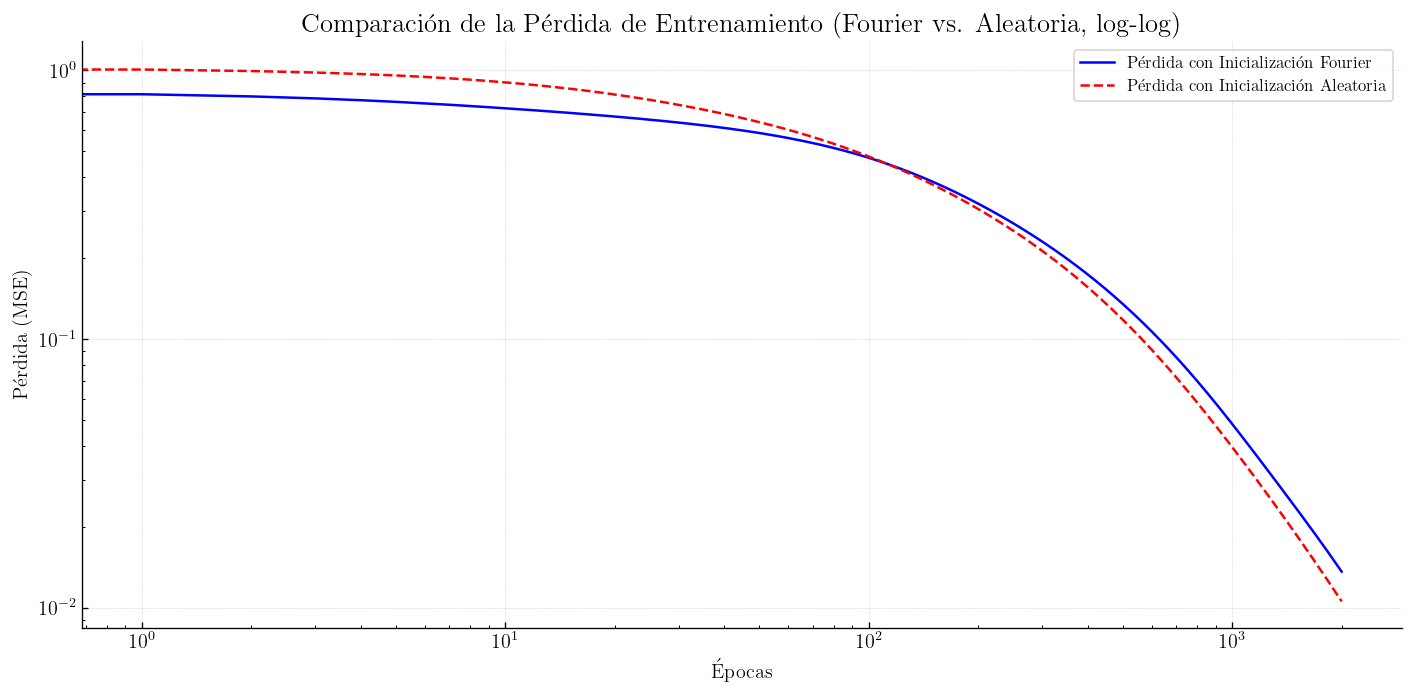

In [24]:
#Fase n°3, comparacion de la perdida del error en el entrenamiento de las redes neuronales

import matplotlib.pyplot as plt

# Asegurarse de que las listas de pérdida sean arrays de JAX o NumPy para un ploteo fácil
loss_fourier_np = jnp.array(loss_fourier)
loss_random_np = jnp.array(loss_random)

# Crear la figura y los ejes para la gráfica
plt.figure(figsize=(12, 6))

# Graficar la pérdida con inicialización de Fourier
plt.loglog(loss_fourier_np, label='Pérdida con Inicialización Fourier', color='blue')

# Graficar la pérdida con inicialización Aleatoria
plt.loglog(loss_random_np, label='Pérdida con Inicialización Aleatoria', color='red', linestyle='--')

# Añadir título y etiquetas a los ejes
plt.title('Comparación de la Pérdida de Entrenamiento (Fourier vs. Aleatoria, log-log)', fontsize=16)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Pérdida (MSE)', fontsize=12)

# Añadir leyenda para identificar las líneas
plt.legend(fontsize=10)

# Añadir una cuadrícula para mejor legibilidad
plt.grid(True, linestyle=':', alpha=0.7)

# Ajustar el diseño para evitar recortes de etiquetas
plt.tight_layout()

# Mostrar la gráfica
plt.show()

### Función de Entrenamiento con Seguimiento del Error Relativo

Para poder medir la velocidad de convergencia en términos de error relativo, necesitamos una versión de la función de entrenamiento que, además de la pérdida, registre el error relativo máximo de la reconstrucción para una señal de ejemplo en cada época.

In [49]:
def train_network_with_error_tracking(params, X_train, original_signal_for_error_calc, epochs=2000, lr=0.1):
    loss_history = []
    max_relative_error_history = []
    epsilon = 1e-8 # Pequeño valor para evitar la división por cero en el error relativo

    for epoch in range(epochs):
        params, loss = update(params, X_train, lr)
        loss_history.append(loss)

        # Calcular la señal reconstruida para la señal original de ejemplo
        # La función 'predict' espera un lote, así que expandimos las dimensiones
        reconstructed_single_signal = predict(params, jnp.expand_dims(original_signal_for_error_calc, axis=0))[0]

        # Calcular el error relativo elemento a elemento
        relative_error = jnp.abs(reconstructed_single_signal - original_signal_for_error_calc) / (jnp.abs(original_signal_for_error_calc) + epsilon)

        # Almacenar el error relativo máximo para esta época
        max_relative_error_history.append(jnp.max(relative_error))

    return params, loss_history, max_relative_error_history

### Análisis de Convergencia para una Señal del Régimen 0

Calcularemos cuántas épocas necesita cada inicialización (Fourier y Aleatoria) para que el error relativo máximo de la reconstrucción de una señal de ejemplo (del Régimen 0) caiga por debajo de 0.1.

In [48]:
# Seleccionar una señal de ejemplo del Régimen 0
sample_signal_regime0 = X_regimen_0[0]

# Generar nuevas claves para asegurar la reinicialización de los parámetros de la red
key_regime0_fourier, key_regime0_random = jax.random.split(jax.random.PRNGKey(5000))

# 1. Re-entrenar con inicialización Fourier y seguimiento del error para la señal de Régimen 0
params_fourier_init_regime0 = init_fourier(t, key_regime0_fourier)
_, _, max_relative_error_history_fourier_regime0 = \
    train_network_with_error_tracking(params_fourier_init_regime0, X_regimen_0, sample_signal_regime0)

# 2. Re-entrenar con inicialización Aleatoria y seguimiento del error para la señal de Régimen 0
params_random_init_regime0 = init_random(t, key_regime0_random)
_, _, max_relative_error_history_random_regime0 = \
    train_network_with_error_tracking(params_random_init_regime0, X_regimen_0, sample_signal_regime0)

# Encontrar el número de épocas para que el error relativo máximo sea menor a 0.1
epochs_fourier_below_0_1 = next((i + 1 for i, err in enumerate(max_relative_error_history_fourier_regime0) if err < 0.1), -1)
epochs_random_below_0_1 = next((i + 1 for i, err in enumerate(max_relative_error_history_random_regime0) if err < 0.1), -1)

print(f"Para una señal del Régimen 0 (Reconstrucción vs Original):")
print(f"  - Inicialización Fourier: {epochs_fourier_below_0_1} épocas para que el error relativo máximo baje de 0.1")
print(f"  - Inicialización Aleatoria: {epochs_random_below_0_1} épocas para que el error relativo máximo baje de 0.1")

Para una señal del Régimen 0 (Reconstrucción vs Original):
  - Inicialización Fourier: -1 épocas para que el error relativo máximo baje de 0.1
  - Inicialización Aleatoria: -1 épocas para que el error relativo máximo baje de 0.1


### Análisis de Convergencia para el Régimen Difícil

Basándonos en análisis previos, el Régimen 2 ha mostrado los errores relativos máximos más altos. A continuación, entrenaremos las redes nuevamente (usando los datos de entrenamiento del Régimen 0) pero monitoreando el error relativo de la reconstrucción para una señal específica del Régimen 2. Esto nos permitirá observar la velocidad de convergencia para un caso más desafiante.

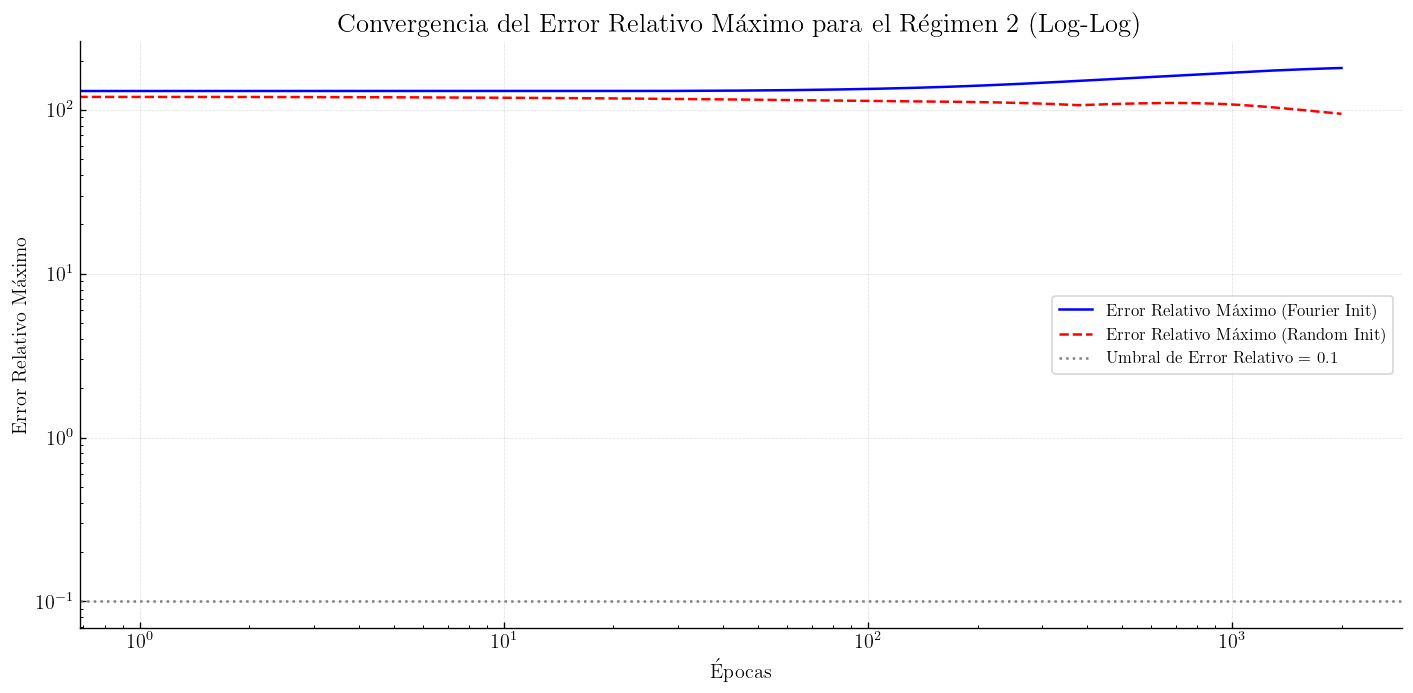

Para una señal del Régimen 2 (Reconstrucción vs Original) - (Régimen Difícil):
  - Inicialización Fourier: -1 épocas para que el error relativo máximo baje de 0.1
  - Inicialización Aleatoria: -1 épocas para que el error relativo máximo baje de 0.1


In [47]:
# Identificar el régimen difícil (Régimen 2)
difficult_regime = 2
sample_signal_difficult = X[y == difficult_regime][0] # Tomar la primera señal del régimen 2

# Generar nuevas claves para la reinicialización de los parámetros de la red
key_difficult_fourier, key_difficult_random = jax.random.split(jax.random.PRNGKey(6000))

# 1. Re-entrenar con inicialización Fourier y seguimiento del error para la señal difícil
params_fourier_init_difficult = init_fourier(t, key_difficult_fourier)
_, _, max_relative_error_history_fourier_difficult = \
    train_network_with_error_tracking(params_fourier_init_difficult, X_regimen_0, sample_signal_difficult)

# 2. Re-entrenar con inicialización Aleatoria y seguimiento del error para la señal difícil
params_random_init_difficult = init_random(t, key_difficult_random)
_, _, max_relative_error_history_random_difficult = \
    train_network_with_error_tracking(params_random_init_difficult, X_regimen_0, sample_signal_difficult)

# Graficar el error relativo máximo vs. épocas para el régimen difícil
plt.figure(figsize=(12, 6))
plt.loglog(jnp.array(max_relative_error_history_fourier_difficult), label='Error Relativo Máximo (Fourier Init)', color='blue')
plt.loglog(jnp.array(max_relative_error_history_random_difficult), label='Error Relativo Máximo (Random Init)', color='red', linestyle='--')

plt.axhline(y=0.1, color='gray', linestyle=':', label='Umbral de Error Relativo = 0.1')

plt.title(f'Convergencia del Error Relativo Máximo para el Régimen {difficult_regime} (Log-Log)', fontsize=16)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Error Relativo Máximo', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Encontrar el número de épocas para que el error relativo máximo sea menor a 0.1 para el régimen difícil
epochs_fourier_difficult_below_0_1 = next((i + 1 for i, err in enumerate(max_relative_error_history_fourier_difficult) if err < 0.1), -1)
epochs_random_difficult_below_0_1 = next((i + 1 for i, err in enumerate(max_relative_error_history_random_difficult) if err < 0.1), -1)

print(f"Para una señal del Régimen {difficult_regime} (Reconstrucción vs Original) - (Régimen Difícil):")
print(f"  - Inicialización Fourier: {epochs_fourier_difficult_below_0_1} épocas para que el error relativo máximo baje de 0.1")
print(f"  - Inicialización Aleatoria: {epochs_random_difficult_below_0_1} épocas para que el error relativo máximo baje de 0.1")